In [ ]:
!pip install kagglehub

In [ ]:
import kagglehub
import os

path = kagglehub.dataset_download("hijest/genre-classification-dataset-imdb")

print("Dataset path:", path)

print(os.listdir(path))

Using Colab cache for faster access to the 'genre-classification-dataset-imdb' dataset.
Dataset path: /kaggle/input/genre-classification-dataset-imdb
['.nfs0000000088cfdfc60000025e', 'Genre Classification Dataset']


In [ ]:

import os
import pandas as pd

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report


# TRAIN DATA
train_file = os.path.join(path, "/kaggle/input/genre-classification-dataset-imdb/Genre Classification Dataset/train_data.txt")

with open(train_file, "r", encoding="utf-8") as f:
    train_lines = f.readlines()

train_data = []

for line in train_lines:
    parts = [p.strip() for p in line.strip().split(":::")]

    if len(parts) >= 4:
        _, title, genre, description = parts[:4]
        train_data.append([description, genre])

df_train = pd.DataFrame(train_data, columns=["plot", "genre"])

# Clean empty plots
df_train = df_train[df_train["plot"].str.strip() != ""]

print("Train shape:", df_train.shape)


# TEST DATA
test_file = os.path.join(path, "/kaggle/input/genre-classification-dataset-imdb/Genre Classification Dataset/test_data.txt")

with open(test_file, "r", encoding="utf-8") as f:
    test_lines = f.readlines()

test_data = []

for line in test_lines:
    parts = [p.strip() for p in line.strip().split(":::")]

    if len(parts) >= 3:
        _, title, description = parts[:3]
        test_data.append(description)

df_test = pd.DataFrame(test_data, columns=["plot"])

# Clean empty plots
df_test = df_test[df_test["plot"].str.strip() != ""]

print("Test shape:", df_test.shape)


# SOLUTION FILE
solution_file = os.path.join(path, "/kaggle/input/genre-classification-dataset-imdb/Genre Classification Dataset/test_data_solution.txt")

with open(solution_file, "r", encoding="utf-8") as f:
    solution_lines = f.readlines()

solution_data = []

for line in solution_lines:
    parts = [p.strip() for p in line.strip().split(":::")]

    if len(parts) >= 4:
        _, title, genre, description = parts[:4]
        solution_data.append(genre)

df_solution = pd.DataFrame(solution_data, columns=["genre"])

print("Solution shape:", df_solution.shape)


# Ensure alignment
min_len = min(len(df_test), len(df_solution))
df_test = df_test.iloc[:min_len]
df_solution = df_solution.iloc[:min_len]

print("Final aligned size:", len(df_test), len(df_solution))


# Define Train/Test
X_train = df_train["plot"]
y_train = df_train["genre"]

X_test = df_test["plot"]
y_test = df_solution["genre"]


# Build Model (TF-IDF + SVM)
model = Pipeline([
    ("tfidf", TfidfVectorizer(
        stop_words="english",
        max_features=5000,
        ngram_range=(1,2)
    )),
    ("clf", LinearSVC(class_weight="balanced"))
])


# Train Model
model.fit(X_train, y_train)


# Predict
y_pred = model.predict(X_test)


# Evaluate
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Train shape: (54214, 2)
Test shape: (54200, 1)
Solution shape: (54200, 1)
Final aligned size: 54200 54200

Classification Report:

              precision    recall  f1-score   support

      action       0.27      0.41      0.33      1314
       adult       0.30      0.54      0.38       590
   adventure       0.17      0.28      0.21       775
   animation       0.13      0.23      0.17       498
   biography       0.03      0.08      0.05       264
      comedy       0.59      0.44      0.50      7446
       crime       0.11      0.25      0.15       505
 documentary       0.77      0.67      0.71     13096
       drama       0.68      0.43      0.53     13612
      family       0.12      0.25      0.17       783
     fantasy       0.09      0.20      0.12       322
   game-show       0.54      0.67      0.60       193
     history       0.05      0.10      0.07       243
      horror       0.49      0.62      0.55      2204
       music       0.39      0.62      0.48       731
    

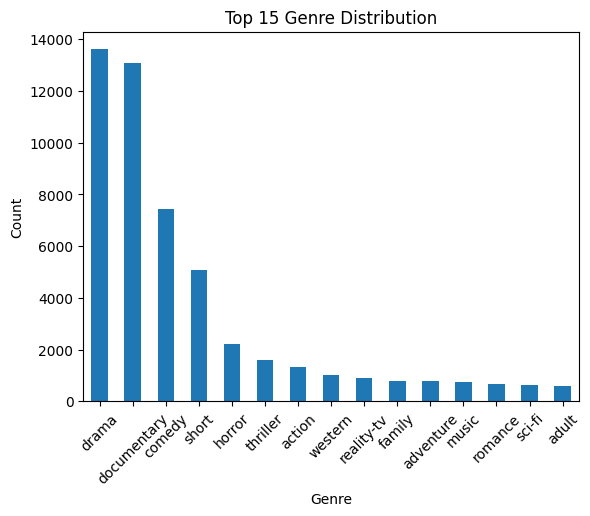

In [ ]:
import matplotlib.pyplot as plt

df_train["genre"].value_counts().head(15).plot(kind="bar")
plt.title("Top 15 Genre Distribution")
plt.xlabel("Genre")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

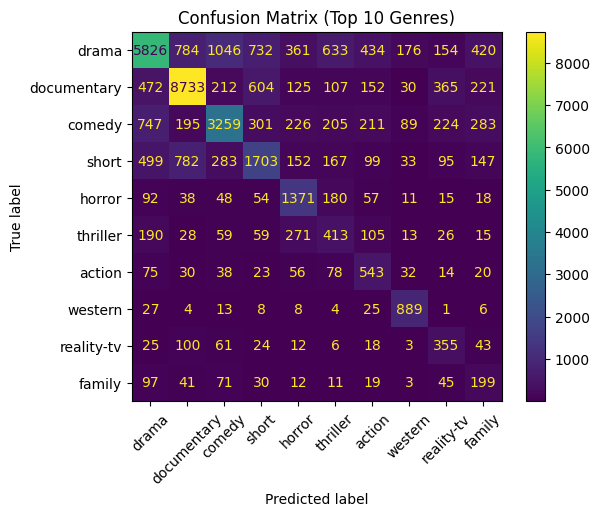

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Get top 10 genres
top_genres = df_train["genre"].value_counts().head(10).index

# Filter test data
mask = y_test.isin(top_genres)

y_test_filtered = y_test[mask]
y_pred_filtered = pd.Series(y_pred)[mask]

# Confusion matrix
cm = confusion_matrix(y_test_filtered, y_pred_filtered, labels=top_genres)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=top_genres)
disp.plot(xticks_rotation=45)
plt.title("Confusion Matrix (Top 10 Genres)")
plt.show()

In [ ]:
import numpy as np
feature_names = model.named_steps['tfidf'].get_feature_names_out()
clf = model.named_steps['clf']

if hasattr(clf, "coef_"):
    for i, genre in enumerate(clf.classes_[:5]):
        top10 = np.argsort(clf.coef_[i])[-10:]
        print(f"\nTop words for {genre}:")
        print([feature_names[j] for j in top10])
else:
    print("Model does not support coefficient-based feature importance")


Top words for action:
['fighter', 'racing', 'chaos', 'dragon', 'skills', 'assassin', 'multiple', 'martial', 'gangsters', 'action']

Top words for adult:
['lesbian', 'fantasy', 'sexy', 'recalls', 'hot', 'double', 'sexual', 'adult', 'lust', 'sex']

Top words for adventure:
['furious', 'thugs', 'treasure', 'cruel', 'adventures', 'chuck', 'tied', 'adventure', 'jungle', 'bondage']

Top words for animation:
['redemption', 'cook', 'guardian', 'crack', 'bbc', 'cat', 'come true', 'adventures', 'animation', 'animated']

Top words for biography:
['christ', 'italy', 'sits', 'skin', 'heritage', 'calling', 'legend', 'psychic', 'correct', 'drinking']


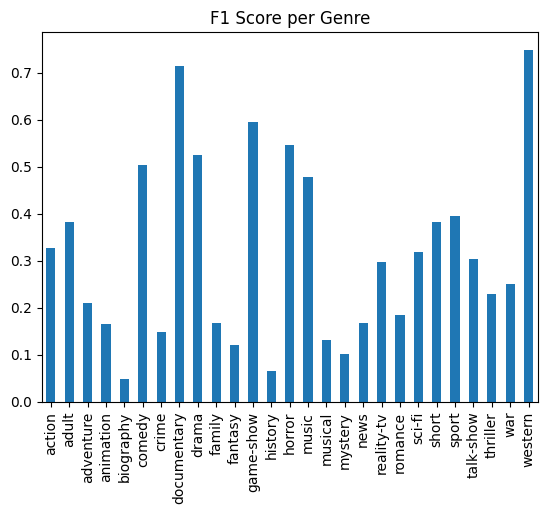

In [ ]:
import pandas as pd
from sklearn.metrics import classification_report

report = classification_report(y_test, y_pred, output_dict=True)
df_report = pd.DataFrame(report).transpose()

df_report["f1-score"][:-3].plot(kind="bar")
plt.title("F1 Score per Genre")
plt.xticks(rotation=90)
plt.show()

# end


**try 2**

Train shape: (54214, 2)
Test size: 54200

SVM Classification Report:

              precision    recall  f1-score   support

      action       0.32      0.46      0.38      1314
       adult       0.40      0.58      0.47       590
   adventure       0.25      0.32      0.28       775
   animation       0.19      0.24      0.21       498
   biography       0.04      0.05      0.04       264
      comedy       0.59      0.52      0.55      7446
       crime       0.15      0.24      0.19       505
 documentary       0.77      0.74      0.75     13096
       drama       0.67      0.51      0.58     13612
      family       0.17      0.25      0.20       783
     fantasy       0.12      0.16      0.14       322
   game-show       0.64      0.72      0.68       193
     history       0.07      0.07      0.07       243
      horror       0.53      0.67      0.59      2204
       music       0.46      0.66      0.54       731
     musical       0.14      0.20      0.17       276
     myster

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(



Logistic Regression Report:

              precision    recall  f1-score   support

      action       0.27      0.41      0.33      1314
       adult       0.30      0.54      0.38       590
   adventure       0.17      0.28      0.21       775
   animation       0.13      0.23      0.17       498
   biography       0.03      0.08      0.05       264
      comedy       0.59      0.44      0.50      7446
       crime       0.11      0.25      0.15       505
 documentary       0.77      0.67      0.71     13096
       drama       0.68      0.43      0.53     13612
      family       0.12      0.25      0.17       783
     fantasy       0.09      0.20      0.12       322
   game-show       0.54      0.67      0.60       193
     history       0.05      0.10      0.07       243
      horror       0.49      0.62      0.55      2204
       music       0.39      0.62      0.48       731
     musical       0.09      0.21      0.13       276
     mystery       0.07      0.16      0.10       3

<Figure size 1000x800 with 0 Axes>

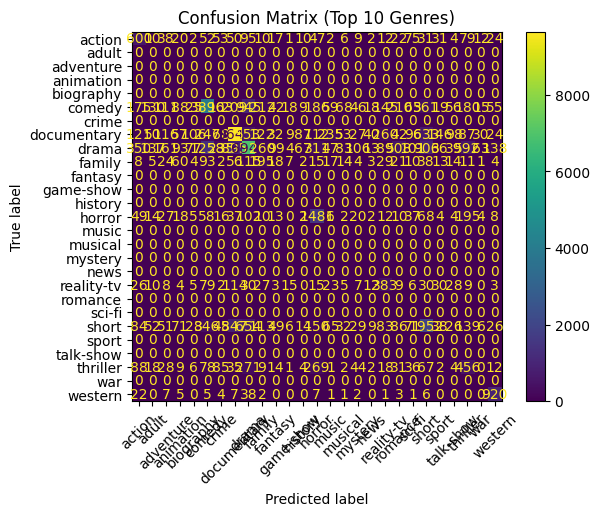

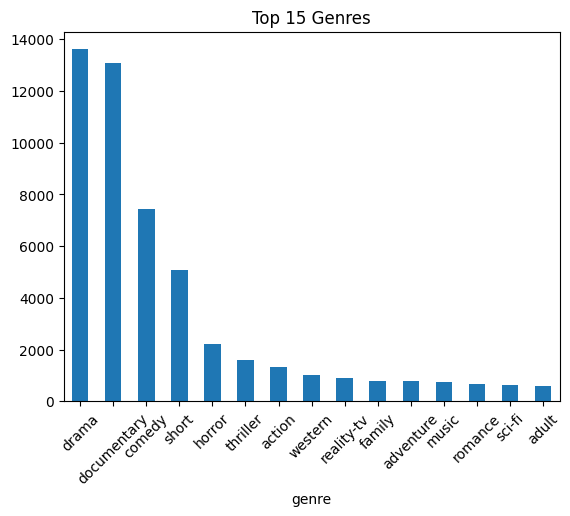

In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

train_file = os.path.join(path, "/kaggle/input/genre-classification-dataset-imdb/Genre Classification Dataset/train_data.txt")

with open(train_file, "r", encoding="utf-8") as f:
    train_lines = f.readlines()

train_data = []

for line in train_lines:
    parts = [p.strip() for p in line.strip().split(":::")]
    if len(parts) >= 4:
        _, title, genre, description = parts[:4]
        train_data.append([description, genre])

df_train = pd.DataFrame(train_data, columns=["plot", "genre"])
df_train = df_train[df_train["plot"].str.strip() != ""]

print("Train shape:", df_train.shape)


# TEST
test_file = os.path.join(path, "/kaggle/input/genre-classification-dataset-imdb/Genre Classification Dataset/test_data.txt")

with open(test_file, "r", encoding="utf-8") as f:
    test_lines = f.readlines()

test_data = []

for line in test_lines:
    parts = [p.strip() for p in line.strip().split(":::")]
    if len(parts) >= 3:
        _, title, description = parts[:3]
        test_data.append(description)

df_test = pd.DataFrame(test_data, columns=["plot"])
df_test = df_test[df_test["plot"].str.strip() != ""]


# SOLUTION
solution_file = os.path.join(path, "/kaggle/input/genre-classification-dataset-imdb/Genre Classification Dataset/test_data_solution.txt")

with open(solution_file, "r", encoding="utf-8") as f:
    solution_lines = f.readlines()

solution_data = []

for line in solution_lines:
    parts = [p.strip() for p in line.strip().split(":::")]
    if len(parts) >= 4:
        _, title, genre, description = parts[:4]
        solution_data.append(genre)

df_solution = pd.DataFrame(solution_data, columns=["genre"])

# ALIGN
min_len = min(len(df_test), len(df_solution))
df_test = df_test.iloc[:min_len]
df_solution = df_solution.iloc[:min_len]

print("Test size:", len(df_test))

X_train = df_train["plot"]
y_train = df_train["genre"]

X_test = df_test["plot"]
y_test = df_solution["genre"]

tfidf = TfidfVectorizer(
    stop_words="english",
    max_features=20000,
    ngram_range=(1,2),
    min_df=3,
    max_df=0.9
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

svm_model = LinearSVC(class_weight="balanced")

svm_model.fit(X_train_tfidf, y_train)

y_pred_svm = svm_model.predict(X_test_tfidf)

print("\nSVM Classification Report:\n")
print(classification_report(y_test, y_pred_svm))

lr_model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    solver="saga",
    n_jobs=-1
)

lr_model.fit(X_train_tfidf, y_train)

y_pred_lr = lr_model.predict(X_test_tfidf)

print("\nLogistic Regression Report:\n")
print(classification_report(y_test, y_pred, zero_division=0))

feature_names = tfidf.get_feature_names_out()

print("\nTop words per genre:\n")

for i, genre in enumerate(lr_model.classes_[:10]):
    top10 = np.argsort(lr_model.coef_[i])[-10:]

    print(f"\n{genre}:")
    print([feature_names[j] for j in top10])

top_genres = df_train["genre"].value_counts().head(10).index

mask = y_test.isin(top_genres)

y_test_f = y_test[mask]
y_pred_f = pd.Series(y_pred_svm)[mask]

plt.figure(figsize=(10, 8))
ConfusionMatrixDisplay.from_predictions(y_test_f, y_pred_f, xticks_rotation=45)
plt.title("Confusion Matrix (Top 10 Genres)")
plt.show()

df_train["genre"].value_counts().head(15).plot(kind="bar")
plt.title("Top 15 Genres")
plt.xticks(rotation=45)
plt.show()